# 기본 셋팅

In [2]:
# ==========================================================
# 1. Import Library
# ==========================================================

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Split & Hyperparameter Tuning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

# Scaling
from sklearn.preprocessing import MinMaxScaler

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# ==========================================================
# 2. Load Dataset
# ==========================================================

df = pd.read_csv("ai4i2020.csv")

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print()

print("=" * 60)
print("Dataset Information")
print("=" * 60)
print(df.info())

print()

print("=" * 60)
print("Machine Failure Distribution")
print("=" * 60)
print(df["Machine failure"].value_counts())

display(df.head())

Dataset Shape
(10000, 14)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# ==========================================================
# 3. Preprocessing
# ==========================================================

# Product ID 제거
df = df.drop(columns=["Product ID"])

# Type One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

# Feature / Target
X = df.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df["Machine failure"]

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=49,

    stratify=y

)

# Scaling
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(
    X_train,
    y_train
)

print("=" * 60)
print("Train Shape")
print("=" * 60)
print(X_train.shape)

print()

print("=" * 60)
print("After SMOTE")
print("=" * 60)
print(pd.Series(y_train_sm).value_counts())

Train Shape
(8000, 8)

After SMOTE
Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [4]:
# ==========================================================
# 4. Result Function
# ==========================================================

results = []

def evaluate_model(model_name, model, X_test, y_test, threshold=0.3):

    proba = model.predict_proba(X_test)

    pred = (proba[:,1] > threshold).astype(int)

    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(y_test, pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred
    )

    plt.title(model_name)
    plt.show()

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1-score": f1
    })

# Hyperparameter

XGBoost - Base
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.36      0.85      0.51        68

    accuracy                           0.94      2000
   macro avg       0.68      0.90      0.74      2000
weighted avg       0.97      0.94      0.95      2000



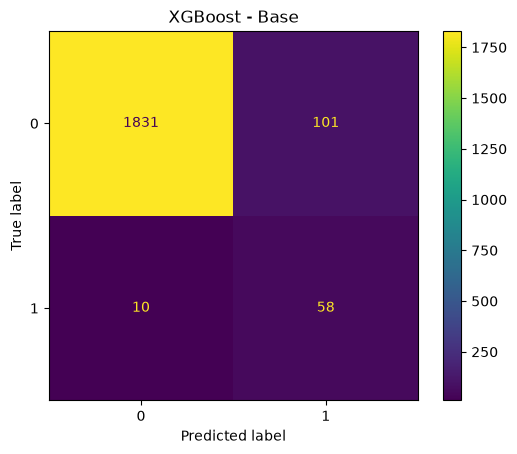

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameter
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
XGBoost - Hyperparameter
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.53      0.79      0.64        68

    accuracy                           0.97      2000
   macro avg       0.76      0.88      0.81      2000
weighted avg       0.98      0.97      0.97      2000



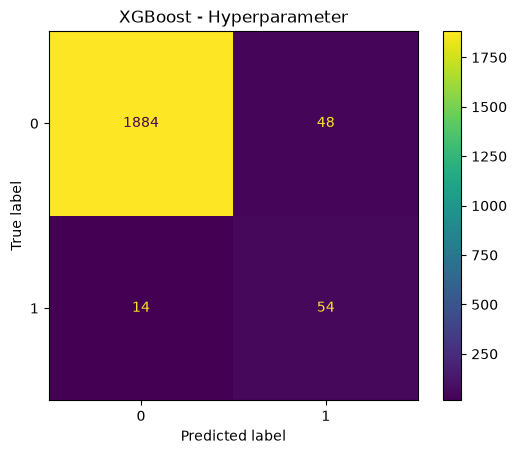

In [5]:
# ==========================================================
# 5. XGBoost - Base Model
# ==========================================================

xgb_base = XGBClassifier(

    random_state=42,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    eval_metric="logloss"

)

xgb_base.fit(
    X_train_sm,
    y_train_sm
)

evaluate_model(
    "XGBoost - Base",
    xgb_base,
    X_test,
    y_test
)

# ==========================================================
# 6. XGBoost - Hyperparameter
# ==========================================================

param_dist = {

    "n_estimators":[100,200,300,500],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "max_depth":[3,5,7,9],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0]

}

xgb_random = RandomizedSearchCV(

    estimator=XGBClassifier(

        random_state=42,

        eval_metric="logloss"

    ),

    param_distributions=param_dist,

    n_iter=20,

    scoring="recall",

    cv=5,

    random_state=42,

    verbose=1,

    n_jobs=1

)

xgb_random.fit(
    X_train_sm,
    y_train_sm
)

print("="*60)
print("Best Parameter")
print("="*60)

print(xgb_random.best_params_)

xgb_best = xgb_random.best_estimator_

evaluate_model(

    "XGBoost - Hyperparameter",

    xgb_best,

    X_test,

    y_test

)

# Feature Engineering

XGBoost - Feature
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1932
           1       0.48      0.88      0.62        68

    accuracy                           0.96      2000
   macro avg       0.74      0.92      0.80      2000
weighted avg       0.98      0.96      0.97      2000



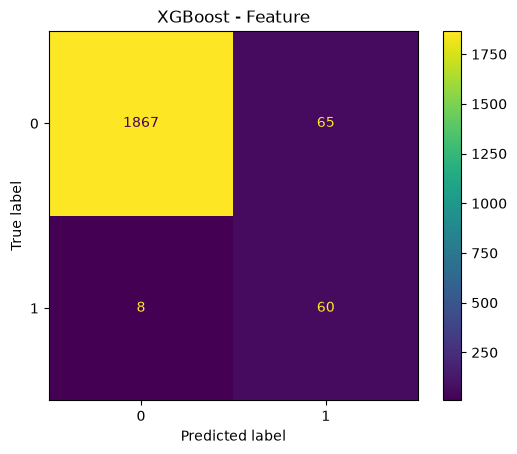

In [6]:
# ==========================================================
# 7. Feature Engineering
# ==========================================================

df_feature = df.copy()

df_feature["Power"] = (
    df_feature["Rotational speed [rpm]"]
    *
    df_feature["Torque [Nm]"]
)

df_feature["Temp_diff"] = (
    df_feature["Process temperature [K]"]
    -
    df_feature["Air temperature [K]"]
)

df_feature["Power_wear"] = (
    df_feature["Power"]
    *
    df_feature["Tool wear [min]"]
)

df_feature["Torque_per_RPM"] = (
    df_feature["Torque [Nm]"]
    /
    (df_feature["Rotational speed [rpm]"] + 1)
)

df_feature["Torque_wear"] = (
    df_feature["Torque [Nm]"]
    *
    df_feature["Tool wear [min]"]
)

df_feature["Temp_Torque"] = (
    df_feature["Temp_diff"]
    *
    df_feature["Torque [Nm]"]
)

df_feature["Temp_ratio"] = (
    df_feature["Process temperature [K]"]
    /
    df_feature["Air temperature [K]"]
)

X = df_feature.drop(columns=[
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

y = df_feature["Machine failure"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=49,
    stratify=y
)

scaler=MinMaxScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

sm=SMOTE(random_state=42)

X_train_sm,y_train_sm=sm.fit_resample(
    X_train,
    y_train
)

xgb_feature = XGBClassifier(

    random_state=42,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    eval_metric="logloss"

)

xgb_feature.fit(
    X_train_sm,
    y_train_sm
)

evaluate_model(

    "XGBoost - Feature",

    xgb_feature,

    X_test,

    y_test

)

# Feature + Hyperparameter

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameter
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost - Feature + Hyperparameter
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.57      0.82      0.67        68

    accuracy                           0.97      2000
   macro avg       0.78      0.90      0.83      2000
weighted avg       0.98      0.97      0.97      2000



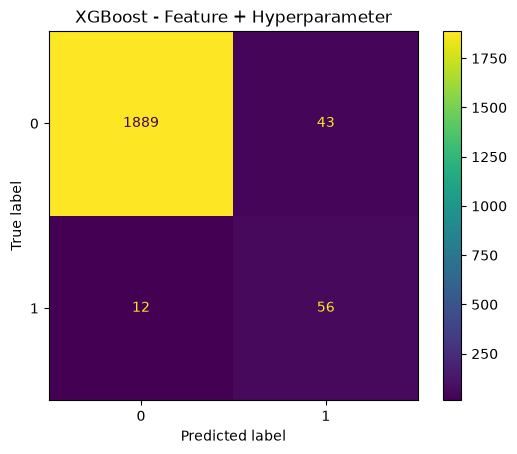

In [7]:
# ==========================================================
# 8. Feature + Hyperparameter
# ==========================================================

xgb_random.fit(
    X_train_sm,
    y_train_sm
)

print("="*60)
print("Best Parameter")
print("="*60)

print(
    xgb_random.best_params_
)

xgb_feature_best = xgb_random.best_estimator_

evaluate_model(

    "XGBoost - Feature + Hyperparameter",

    xgb_feature_best,

    X_test,

    y_test

)

# Feature Importance + Result

In [8]:
# ==========================================================
# 9. Result
# ==========================================================

result_df = pd.DataFrame(results)

display(result_df)

display(
    result_df.sort_values(
        by="F1-score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1-score
0,XGBoost - Base,0.9445,0.364780,0.852941,0.511013
1,XGBoost - Hyperparameter,0.9690,0.529412,0.794118,0.635294
2,XGBoost - Feature,0.9635,0.480000,0.882353,0.621762
3,XGBoost - Feature + Hyperparameter,0.9725,0.565657,0.823529,0.670659


,Model,Accuracy,Precision,Recall,F1-score
3,XGBoost - Feature + Hyperparameter,0.9725,0.565657,0.823529,0.670659
1,XGBoost - Hyperparameter,0.9690,0.529412,0.794118,0.635294
2,XGBoost - Feature,0.9635,0.480000,0.882353,0.621762
0,XGBoost - Base,0.9445,0.364780,0.852941,0.511013
